## EDA

### Problem Statement:

The banking churn prediction dataset (uploaded in the same folder) contains different attributes of the customers of the bank and whether they have churned or not.
Churning means closing the relationship with the bank. Following are the descriptions of the columns in the dataset.

- `customer_id`: Unique identifier for each customer.
- `vintage`: The duration of the customer's relationship with the company.
- `age`: Age of the customer.
- `gender`: Gender of the customer.
- `dependents`: Number of dependents the customer has.
- `occupation`: The occupation of the customer.
- `city`: City in which the customer is located.
- `customer_nw_category`: Net worth category of the customer.
- `branch_code`: Code identifying the branch associated with the customer.
- `current_balance`: Current balance in the customer's account.
- `previous_month_end_balance`: Account balance at the end of the previous month.
- `average_monthly_balance_prevQ`: Average monthly balance in the previous quarter.
- `average_monthly_balance_prevQ2`: Average monthly balance in the second previous quarter.
- `current_month_credit`: Credit amount in the current month.
- `previous_month_credit`: Credit amount in the previous month.
- `current_month_debit`: Debit amount in the current month.
- `previous_month_debit`: Debit amount in the previous month.
- `current_month_balance`: Account balance in the current month.
- `previous_month_balance`: Account balance in the previous month.
- `churn`: The target variable indicating whether the customer has churned (1 for churned, 0 for not churned).
- `last_transaction`: Timestamp of the customer's last transaction.


Your task is to perform exploratory data analysis (EDA) on Banking Churn Prediction dataset. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

1 ) Load data and basic dataset information

In [8]:
df = pd.read_csv("banking_churn_prediction.csv")

df.shape

df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


2) column information

In [15]:

df.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

In [21]:
# need to drop custoer_id from analyssi
df = df.drop("customer_id", axis=1)

In [30]:
# convert categorical columns
categorical_cols = [
    "gender",
    "occupation",
    "city",
    "customer_nw_category",
    "branch_code"
]

In [31]:
df[categorical_cols] = df[categorical_cols].astype("category")

# convert datetime
df["last_transaction"] = pd.to_datetime(df["last_transaction"])

In [32]:
df["days_since_last_txn"] = (
    df["last_transaction"].max() - df["last_transaction"]
).dt.days

In [33]:
df.isnull().sum()

vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                  3223
days_since_last_txn               3223
dtype: int64

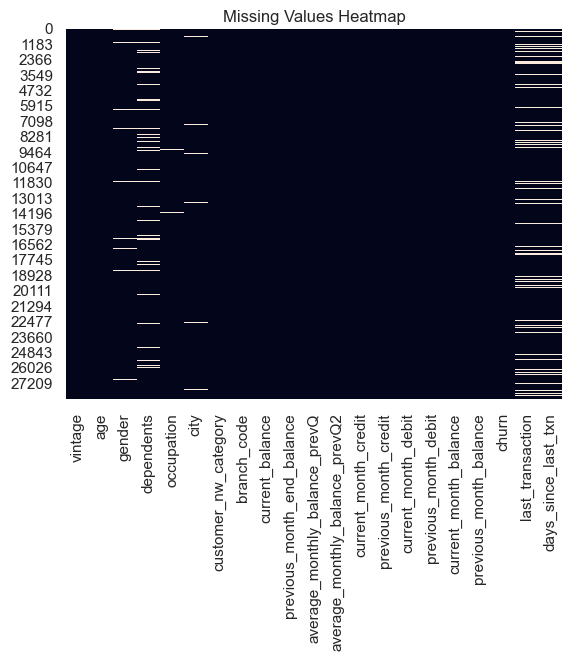

In [34]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [35]:
df.describe()

,vintage,age,dependents,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,days_since_last_txn
count,28382.000000,28382.000000,25919.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000,25159,25159.000000
mean,2091.144105,48.208336,0.347236,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329,2019-10-22 00:03:08.878731520,69.997814
min,73.000000,1.000000,0.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000,2018-12-31 00:00:00,0.000000
25%,1958.000000,36.000000,0.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000,2019-09-27 00:00:00,11.000000
50%,2154.000000,46.000000,0.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000,2019-12-01 00:00:00,30.000000
75%,2292.000000,60.000000,0.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000,2019-12-20 00:00:00,95.000000
max,2476.000000,90.000000,52.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000,2019-12-31 00:00:00,365.000000
std,272.676775,17.807163,0.997661,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571,NaN,86.341098


In [37]:
df.describe(include='category')

,gender,occupation,city,customer_nw_category,branch_code
count,27857,28302,27579.0,28382,28382
unique,2,5,1604.0,3,3185
top,Male,self_employed,1020.0,2,19
freq,16548,17476,3479.0,14559,145


In [38]:
df["churn"].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

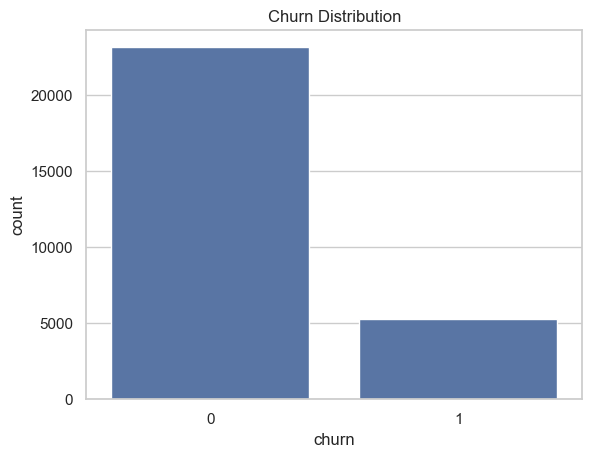

In [39]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

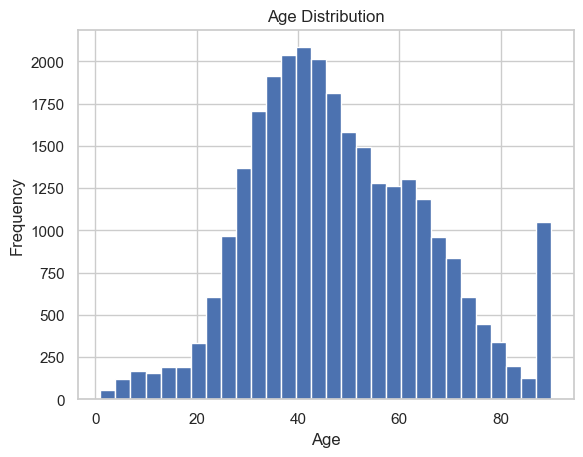

In [40]:
#Age distribution

plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

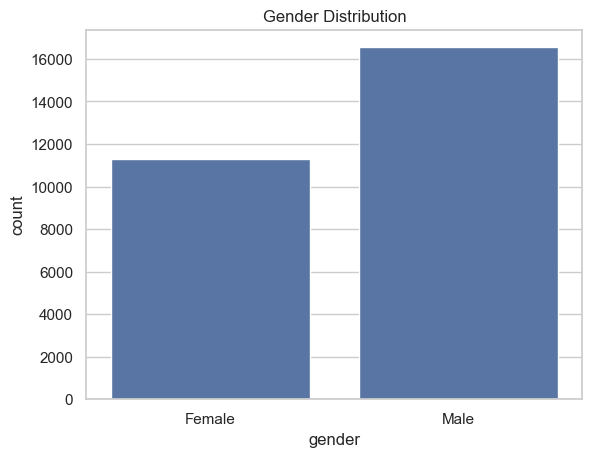

In [41]:
#Gender distribution

sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

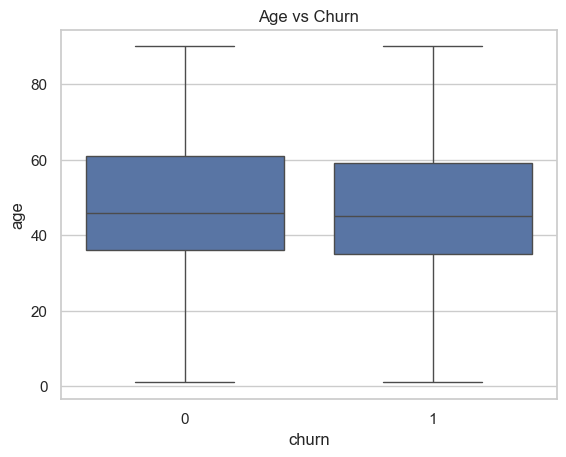

In [42]:
#Age vs churn

sns.boxplot(x="churn", y="age", data=df)
plt.title("Age vs Churn")
plt.show()

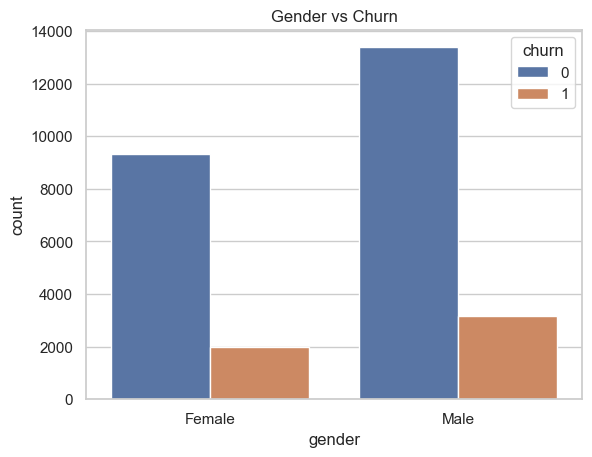

In [43]:
#gender vs churn
sns.countplot(x="gender", hue="churn", data=df)
plt.title("Gender vs Churn")
plt.show()

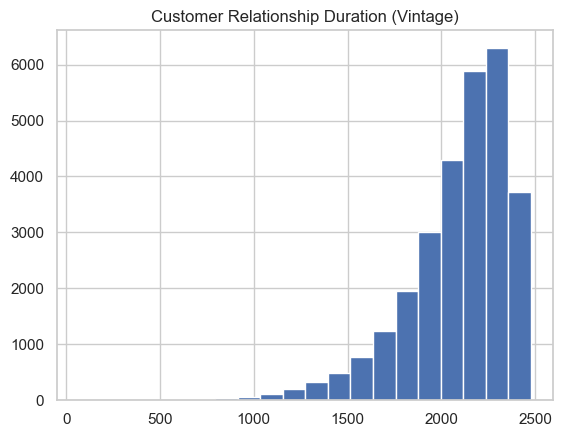

In [44]:
#vintage distribution
plt.hist(df["vintage"], bins=20)
plt.title("Customer Relationship Duration (Vintage)")
plt.show()

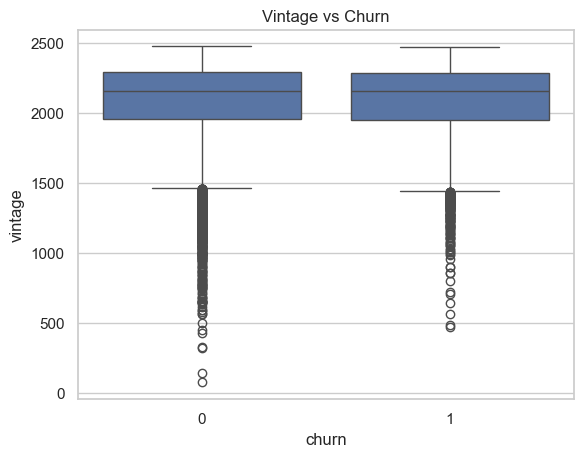

In [45]:
#vintage vs churn

sns.boxplot(x="churn", y="vintage", data=df)
plt.title("Vintage vs Churn")
plt.show()

-> The median vintage for both groups (churn = 0 and churn = 1) is very similar.

Conclusion:

Customers who churn and those who stay have almost the same typical relationship duration.

So vintage alone may not strongly explain churn.

#Financial balance Analysis :

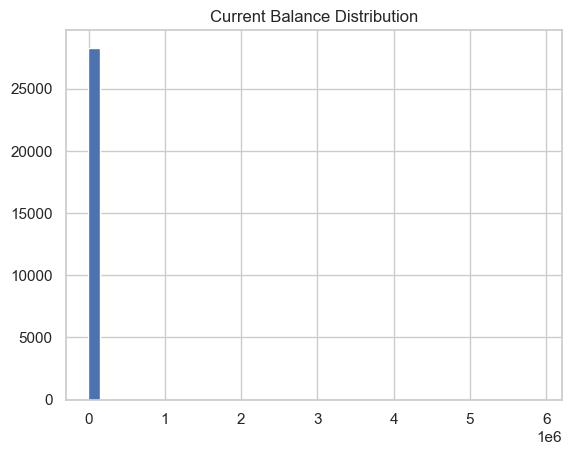

In [46]:
plt.hist(df["current_balance"], bins=40)
plt.title("Current Balance Distribution")
plt.show()

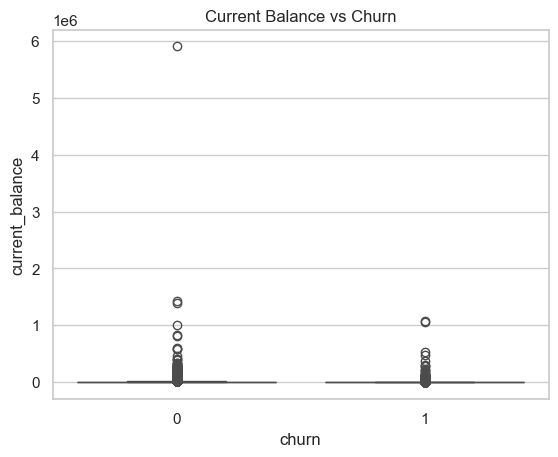

In [47]:
sns.boxplot(x="churn", y="current_balance", data=df)
plt.title("Current Balance vs Churn")
plt.show()

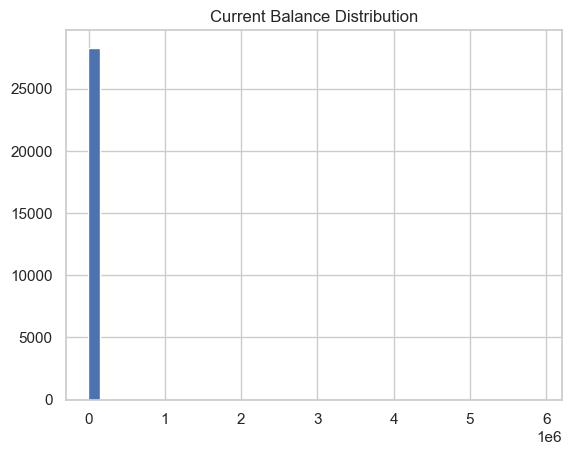

In [51]:
#Current balance analysis

plt.hist(df["current_balance"], bins=40)
plt.title("Current Balance Distribution")
plt.show()

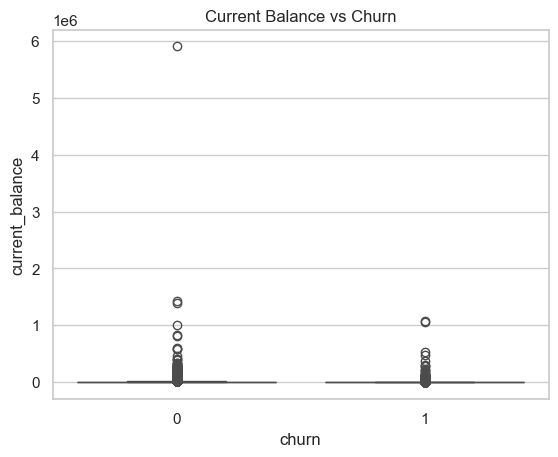

In [52]:
#Balance vs churn analysis
sns.boxplot(x="churn", y="current_balance", data=df)
plt.title("Current Balance vs Churn")
plt.show()

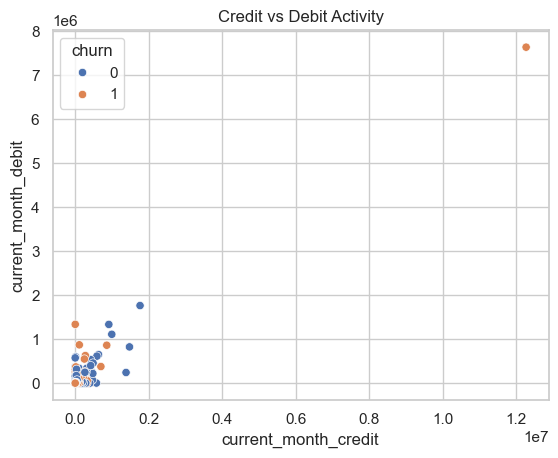

In [53]:
#credit and debit activity

sns.scatterplot(
    x="current_month_credit",
    y="current_month_debit",
    hue="churn",
    data=df
)
plt.title("Credit vs Debit Activity")
plt.show()

In [54]:
df["days_since_last_txn"] = (
    df["last_transaction"].max() - df["last_transaction"]
).dt.days

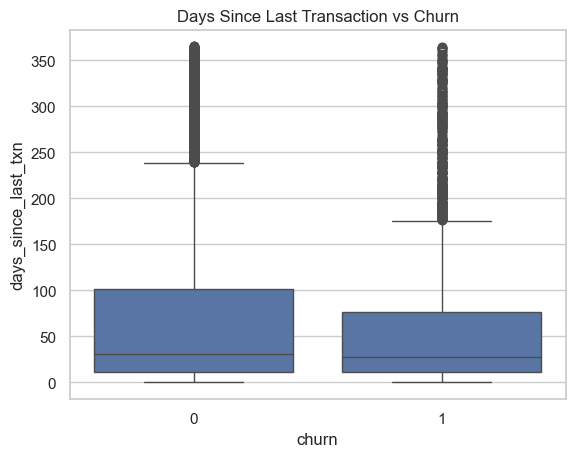

In [55]:
sns.boxplot(x="churn", y="days_since_last_txn", data=df)
plt.title("Days Since Last Transaction vs Churn")
plt.show()

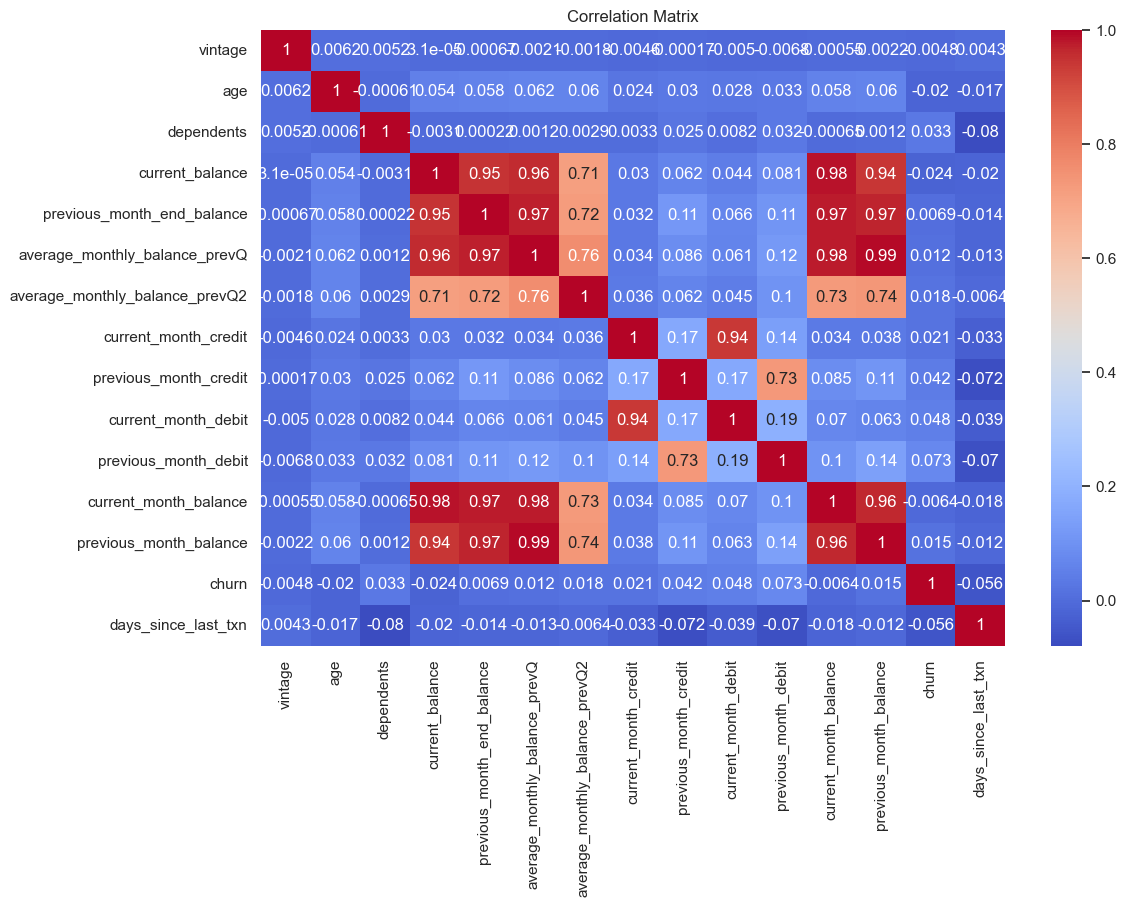

In [56]:
#corelation 
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

we can remove highly corelated features. (marked in red).

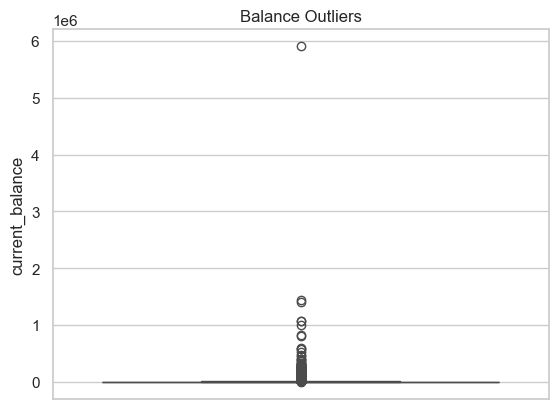

In [57]:
sns.boxplot(df["current_balance"])
plt.title("Balance Outliers")
plt.show()